In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from Layers import Linear,Tanh,BatchNorm1d,fold_bn_into_linear,distribution
import torch.nn.functional as F 

In [3]:
n_emb=10
max_steps=100000
batch_size=32
block_size=3
n_hidden=100
vocab_size=27
layers=[
    Linear(n_emb*block_size,n_hidden,bias=False),
    BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),
    BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),
    BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),
    BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),
    BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size)
]
C=torch.randn((vocab_size,n_emb))
parameters=[p for layer in layers for p in layer.parameters()]+[C]


In [4]:
for p in parameters:
    p.requires_grad=True

In [5]:
lossi=[]
ud=[]

In [6]:
from Layers import Xtr,Ytr

for i in range(max_steps):
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad=None
    loss.backward()
    lr=0.1 if i<10000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad
    
    if i%10000==0:
        print(f'{i}/{max_steps}:{loss.item()}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([((lr*p.grad).std()/p.data.std()).log10().item() 
        for p in parameters
        ])
    



0/100000:3.6260883808135986


10000/100000:1.9303061962127686
20000/100000:1.7254562377929688
30000/100000:1.8364068269729614
40000/100000:2.512779951095581
50000/100000:2.180670976638794
60000/100000:1.9963289499282837
70000/100000:2.1975412368774414
80000/100000:1.7774896621704102
90000/100000:1.8027898073196411


In [11]:
def save_model(path, C, layers):
    ckpt = {
        "C": C.detach().clone(),
        "layers": []
    }

    for layer in layers:
        state = {"type": layer.__class__.__name__}

        if isinstance(layer, Linear):
            state["weight"] = layer.weight.detach().clone()
            state["bias"] = None if layer.bias is None else layer.bias.detach().clone()

        elif isinstance(layer, BatchNorm1d):
            state["gamma"] = layer.gamma.detach().clone()
            state["beta"] = layer.beta.detach().clone()
            state["running_mean"] = layer.running_mean.detach().clone()
            state["running_var"] = layer.running_var.detach().clone()

        ckpt["layers"].append(state)

    torch.save(ckpt, path)
def load_model(path, C, layers):
    ckpt = torch.load(path)

    with torch.no_grad():
        C.copy_(ckpt["C"])

        for layer, state in zip(layers, ckpt["layers"]):
            if isinstance(layer, Linear):
                layer.weight.copy_(state["weight"])
                if layer.bias is not None and state["bias"] is not None:
                    layer.bias.copy_(state["bias"])

            elif isinstance(layer, BatchNorm1d):
                layer.gamma.copy_(state["gamma"])
                layer.beta.copy_(state["beta"])
                layer.running_mean.copy_(state["running_mean"])
                layer.running_var.copy_(state["running_var"])

    for p in [p for layer in layers for p in layer.parameters()] + [C]:
        p.requires_grad = True

In [12]:
save_model("model.pt", C, layers)

In [ ]:
# load_model("model.pt", C, layers)

layer 2 (Tanh): mean +0.04, std 0.41, saturated: 0.00%
layer 5 (Tanh): mean +0.13, std 0.42, saturated: 1.00%
layer 8 (Tanh): mean -0.01, std 0.53, saturated: 0.00%
layer 11 (Tanh): mean +0.05, std 0.68, saturated: 0.00%
layer 14 (Tanh): mean +0.08, std 0.90, saturated: 14.00%


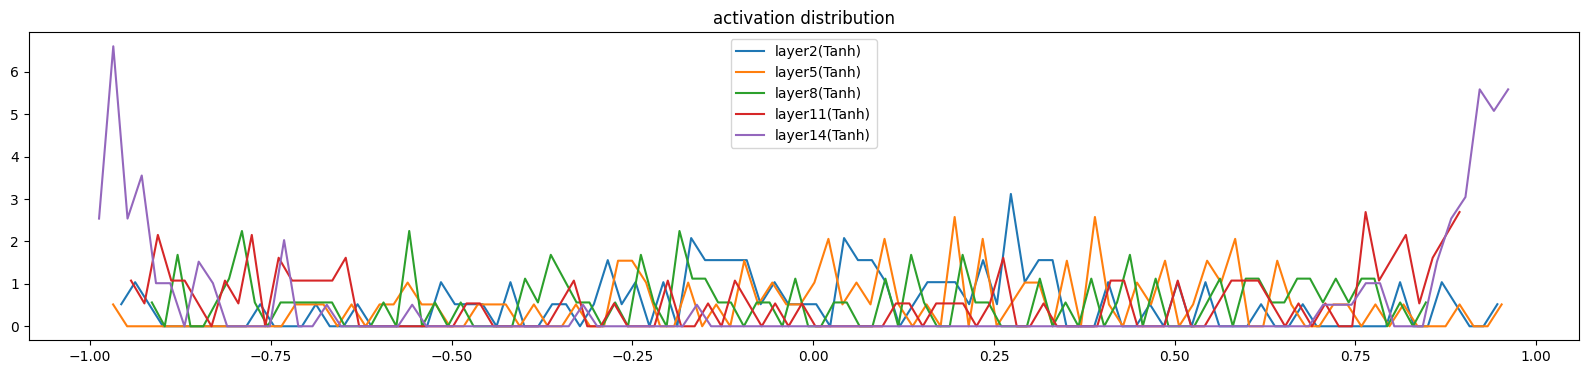

In [13]:
distribution(layers)

layer 2 (Tanh): mean +0.01, std 0.65, saturated: 6.12%
layer 5 (Tanh): mean -0.00, std 0.67, saturated: 6.72%
layer 8 (Tanh): mean -0.01, std 0.68, saturated: 5.69%
layer 11 (Tanh): mean +0.00, std 0.68, saturated: 5.66%
layer 14 (Tanh): mean +0.01, std 0.69, saturated: 6.34%

平均在5-6和之前的15-20比有了显著的进步

In [37]:
fused_layers = []
i = 0

while i < len(layers):
    layer = layers[i]

    if (
        i + 1 < len(layers)
        and isinstance(layer, Linear)
        and isinstance(layers[i + 1], BatchNorm1d)
    ):
        bn = layers[i + 1]
        new_weight, new_bias = fold_bn_into_linear(layer, bn)

        fused_linear = Linear(layer.weight.shape[0], layer.weight.shape[1])
        fused_linear.weight = new_weight.detach().clone()
        fused_linear.bias = new_bias.detach().clone().squeeze()

        fused_layers.append(fused_linear)
        i += 2
    else:
        fused_layers.append(layer)
        i += 1

In [38]:
import torch.nn.functional as F
from Layers import itos
@torch.no_grad()
def generate_name(layers,max_len=20):
    context=[0]*block_size
    out=[]
    while True:
        x=torch.tensor([context])
        emb=C[x]
        x=emb.view(1,-1)
        for layer in layers:
            x=layer(x)
        probs=F.softmax(x,dim=1)
        ix=torch.multinomial(probs,num_samples=1).item()

        if ix==0 or len(out)>=max_len:
            break
        out.append(itos[ix])
        context=context[1:]+[ix]
    return ''.join(out)


In [39]:
for _ in range(20):
    print(generate_name(fused_layers))

elyn
cortu
zour
jobo
glei
adurzella
anvika
thann
dayabsi
mos
yurius
ren
ndos
vik
caan
cori
marjeen
mathanie
joadelas
luolynn


In [29]:
10**lossi[-1]

2.112728857390976

In [ ]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}